# 1. CONFIGURACIÓN GENERAL DEL MODELO Y ESTIMACIÓN DE DATOS REQUERIDOS

En esta sección inicial se detalla la configuración de hiperparámetros del sistema y el análisis del volumen de datos necesarios frente a los reales para el hecho de **Evaluación de Proveedores**.

## 1.1 Volumen de Datos Requeridos y Disponibles
* **Datos Disponibles en MongoDB:** Se consultaron **3,900 registros** de la colección `fact_evaluacion_proveedores` de la base de datos `ProyectoBueno`.
* **Cálculo de Estimación Teórica de Datos Requeridos:**
  Para una arquitectura de capas ocultas $H_1=64$ y $H_2=32$ con $K=3$ clases de salida (Bajo Desempeño (0), Desempeño Medio (1), Alto Desempeño (2)):
  - **Conexiones Capa 1 ($P_{12}$):** $(H_1 + 1) \times H_2 = (64 + 1) \times 32 = 2,080$ pesos.
  - **Conexiones Capa 2 ($P_{23}$):** $(H_2 + 1) \times K = (32 + 1) \times 3 = 99$ pesos.
  - **Complejidad de Conexión del Modelo ($C_{complexity}$):** $P_{12} \times P_{23} = 2,080 \times 99 = 205,920$ conexiones.
  - **Volumen de Datos Requerido (Regla Empírica $10 \times C_{complexity}$):** Se estimarían idealmente **2,059,200 registros** para un entrenamiento sin sobreajuste.
  - **Justificación de Datos Reales:** Al disponer únicamente de **3,900 registros reales**, se implementaron mecanismos avanzados de regularización (penalización L2, validación cruzada estratificada de 5 pliegues y entrenamiento controlado) para asegurar la robustez del modelo y evitar el sobreajuste.

## 1.2 Hiperparámetros de la Red Neuronal (Paso a Paso)
Para cumplir con los requisitos de diseño del modelo, se definieron y enumeraron los siguientes hiperparámetros:
1. **Porcentaje de Test (Partición de Datos):** 20% para pruebas (`test_size=0.20`) y 80% para entrenamiento.
2. **Inicialización de Pesos (Weight Initialization):** Inicialización uniforme de **He / Xavier** para evitar desvanecimiento del gradiente.
3. **Función de Activación (Activation Function):** Función **Sigmoide** en capas ocultas y **Softmax** en la capa de salida.
4. **Forma de Optimizar los Pesos (Optimization Method):** Descenso de Gradiente Estocástico (**SGD**) con regularización L2.
5. **Número de Capas Ocultas (Hidden Layers):** **2 capas ocultas** en el modelo.
6. **Número de Neuronas por Capa Oculta (Neurons per Hidden Layer):** Búsqueda en cuadrícula (*Grid Search*) de arquitecturas: $(64, 32)$, $(32, 20)$ y $(16, 10)$ neuronas.
7. **Épocas (Epochs):** 150 épocas por pliegue en validación cruzada y 1000 épocas para el modelo final.
8. **Matriz de Confusión (Confusion Matrix):** Generada al final de la evaluación para mostrar la clasificación por categoría de Evaluación de Proveedores: Bajo Desempeño (0), Desempeño Medio (1), Alto Desempeño (2).


# Red Neuronal Artificial (MLP) Manual - `fact_evaluacion_proveedores.json`
## Predicción de: **Entrega a Tiempo (Evaluación de Proveedores)**
Este notebook implementa y evalúa una **Red Neuronal Artificial (Perceptrón Multicapa) desde cero utilizando únicamente NumPy y Pandas**. 

La arquitectura de la red neuronal refleja fielmente el principio de que **una red neuronal es un conjunto de regresiones logísticas apiladas**:
- **Capas Ocultas (32 y 20 Neuronas):** Contiene neuronas independientes con función de activación Sigmoide (la función logística). Cada neurona realiza una regresión logística paralela de los inputs o de las activaciones de la capa anterior.
- **Capa de Salida:** Realiza una regresión logística (con Sigmoide) sobre las salidas de la segunda capa oculta para problemas binarios, o una regresión logística multinomial (con Softmax) para problemas multiclase.

### Metodología Implementada (Basada en la Pizarra - Imagen 3):
1. **Carga y Preprocesamiento de Datos:** Aplanamiento del JSON, cálculo del target, eliminación de IDs/metadatos y codificación One-Hot de categóricos con normalización de numéricos.
2. **Balanceo del Dataset:** Aplicación de sobremuestreo aleatorio para balancear la distribución de las clases.
3. **Validación Cruzada en 5 Folds ($J = 5$):** División estratificada. En cada iteración, inicializamos los pesos aleatoriamente $W^{(k)} = \text{rand}(d, T)$ para entrenar sobre el 80% y testear sobre el 20%.
4. **Validación con Hiperparámetros:** Búsqueda en rejilla (Grid Search) sobre diferentes tasas de aprendizaje (`lr`) y coeficientes de regularización L2 (`lambda_l2`) para ajustar el comportamiento de los pesos.
5. **Exportación Estructurada:** Generación de 6 reportes en Excel detallando pesos, métricas finales, predicciones e historial de épocas.
6. **Dashboard Gráfico Premium y Diagrama de Red:** Generación de curvas de aprendizaje (Loss/Acc), matriz de confusión, distribución de probabilidades, visualización t-SNE 2D y el diagrama estructural de la red neuronal.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
import os
import json
import pymongo
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo visual premium
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.family'] = 'sans-serif'

# Crear directorio de outputs
os.makedirs('outputs', exist_ok=True)
print("Entorno inicializado correctamente.")



Entorno inicializado correctamente.


In [2]:
# Cargar JSON crudo desde la raíz
# Cargar datos desde MongoDB
import pymongo
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["ProyectoBueno"]
collection = db["fact_evaluacion_proveedores"]
data = list(collection.find())

# Aplanar registros recursivamente
def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        elif isinstance(v, list):
            items.append((new_key, str(v)))
        else:
            items.append((new_key, v))
    return dict(items)

flat_data = [flatten_dict(record) for record in data]
df = pd.DataFrame(flat_data)
print(f"Dimensiones iniciales aplanadas: {df.shape}")

# Calcular columna target
df["y_desempeno"] = pd.cut(df["calificacion_entrega"], bins=[-np.inf, 2, 4, np.inf], labels=[0, 1, 2]).astype(int)
print(f"Target 'y_desempeno' agregado. Distribución original:")
print(df["y_desempeno"].value_counts(dropna=False))



Dimensiones iniciales aplanadas: (3900, 13)
Target 'y_desempeno' agregado. Distribución original:
y_desempeno
0    2044
1    1662
2     194
Name: count, dtype: int64


# Preprocesamiento de Datos Paso a Paso
En esta sección realizaremos la preparación de los datos para la red neuronal.
El **Target (y)** para este modelo es `y_desempeno`, el cual representa: **Desempeño de Entrega (Evaluación de Proveedores - Multiclase)**.
La fórmula de cálculo del target es:
$$y_{\text{desempeno}} = \begin{cases} 1 & \text{si } \text{entregado\_a\_tiempo} = 0 \quad (\text{A Tiempo}) \\ 0 & \text{en caso contrario} \quad (\text{Tardía}) \end{cases}$$
A continuación, realizaremos los pasos de limpieza, codificación y normalización de forma secuencial y explicada.


## Paso 1: Eliminación de Datos No Útiles e Imputación de Nulos
Las llaves primarias, IDs técnicos, códigos de barras, nombres de clientes/productos, correos, teléfonos y fechas no aportan información generalizable para el aprendizaje de la red neuronal y aumentan artificialmente la dimensionalidad de forma inútil, por lo que deben eliminarse.
También realizamos la imputación de nulos para evitar errores matemáticos durante el entrenamiento:
- **Variables Numéricas:** Imputación con la **Mediana** del atributo para ser robusto a outliers.
- **Variables Categóricas:** Imputación con la **Moda** (el valor más común) o con la etiqueta `'UNKNOWN'` si no hay moda.


In [3]:
# Paso 1: Limpieza de columnas e imputación de nulos
shape_inicial = df.shape
print(f"Dimensiones iniciales del dataset (con target): {shape_inicial}")
print(f"Número total de características iniciales: {shape_inicial[1] - 1}")

cols_to_drop = []
for col in df.columns:
    col_lower = col.lower()
    
    # IDs y llaves técnicas
    is_id = (
        col_lower == 'id' or col_lower == '_id' or col_lower == '_collection' or 
        col_lower.startswith('id_') or col_lower.endswith('_id') or
        '_id_' in col_lower or 'id_venta_dw' in col_lower
    )
    
    # Datos de contacto o códigos nominales únicos
    is_contact_or_code = (
        'telefono' in col_lower or 'correo' in col_lower or 
        'codigo_barras' in col_lower or 'codigo_producto' in col_lower or 
        'codigo_venta' in col_lower or 'cliente_nombre' in col_lower or
        'nombre_cliente' in col_lower or 'nombre_producto' in col_lower or
        'nombre_proveedor' in col_lower or 'nombre_sucursal' in col_lower or
        'nombre_contacto' in col_lower or 'cliente_fecha_nacimiento' in col_lower
    )
    
    # Fechas
    is_date = (
        col_lower.endswith('_fecha') or col_lower.endswith('_hora') or 
        col_lower == 'fecha' or col_lower == 'hora' or col_lower == 'tiempo_fecha'
    )
    
    # Evitar eliminar el target
    if (is_id or is_contact_or_code or is_date) and col != "y_desempeno":
        cols_to_drop.append(col)

# Droppear columnas identificadas
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Columnas eliminadas ({len(cols_to_drop)}): {cols_to_drop}")
print(f"Dimensiones tras limpiar IDs y metadatos: {df.shape}")
print(f"Número de características tras limpieza: {df.shape[1] - 1}")

# Imputación de nulos
nulos_detectados = df.isnull().sum().sum()
if nulos_detectados > 0:
    print(f"Nulos detectados en el dataset: {nulos_detectados}. Imputando...")
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype in ['int64', 'float64', 'int32', 'float32']:
                df[col] = df[col].fillna(df[col].median())
            else:
                mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else 'UNKNOWN'
                df[col] = df[col].fillna(mode_val)
    print("Imputación completada (Mediana para numéricos, Moda para categóricos).")
else:
    print("No se detectaron valores nulos en el dataset.")


Dimensiones iniciales del dataset (con target): (3900, 14)
Número total de características iniciales: 13
Columnas eliminadas (1): ['_id']
Dimensiones tras limpiar IDs y metadatos: (3900, 13)
Número de características tras limpieza: 12
No se detectaron valores nulos en el dataset.


## Paso 2: Codificación de Variables Categóricas (One-Hot Encoding)
La red neuronal requiere entradas numéricas y no puede procesar strings categóricos de forma directa. Usamos la técnica de **One-Hot Encoding** para convertir variables categóricas nominales en vectores binarios.
Para una característica $X_j$ con $K$ categorías distintas $\{c_1, c_2, \dots, c_K\}$, One-Hot Encoding genera $K$ nuevas columnas binarias:
$$E_{j,k}(x) = \begin{cases} 1 & \text{si } X_j(x) = c_k \\ 0 & \text{en caso contrario} \end{cases}$$
Esto previene que el modelo asuma una relación ordinal inexistente entre las categorías.


In [4]:
# Paso 2: One-Hot Encoding
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if "y_desempeno" in categorical_cols:
    categorical_cols.remove("y_desempeno")

print(f"Variables categóricas a codificar ({len(categorical_cols)}): {categorical_cols}")

df = pd.get_dummies(df, columns=categorical_cols, dtype=int)
print(f"Dimensiones tras One-Hot Encoding: {df.shape}")
print(f"Número total de características finales: {df.shape[1] - 1}")


Variables categóricas a codificar (1): ['origen']
Dimensiones tras One-Hot Encoding: (3900, 14)
Número total de características finales: 13


## Paso 3: Separación de Variables y Normalización
Separamos el target $y$ de las características de entrada $X$. Luego aplicamos una transformación por cuantiles (`QuantileTransformer`) con distribución normal.
Este preprocesamiento normaliza las características continuas, haciéndolas robustas a outliers y distribuyendo los datos según una campana de Gauss. La fórmula para mapear una variable aleatoria continua $X$ a una distribución normal estándar es:
$$X' = \Phi^{-1}(U(X))$$
Donde $U(X) = F(X)$ es la función de distribución acumulada (CDF) empírica estimada a partir de los datos, y $\Phi^{-1}$ es la función cuantil de la distribución normal estándar (inversa de la CDF normal).


In [5]:
# Paso 3: Separación y normalización (Split-First)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
import numpy as np
import pandas as pd
import joblib
import os

y = df["y_desempeno"].values.astype(int)
X = df.drop(columns=["y_desempeno"]).values.astype(float)
feature_names = df.drop(columns=["y_desempeno"]).columns.tolist()

# Split-First Protocol
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_train_scaled = qt.fit_transform(X_train)
X_test_scaled = qt.transform(X_test)

os.makedirs("outputs", exist_ok=True)
joblib.dump(qt, "outputs/quantile_transformer.joblib")

print(f"Split completo:")
print(f"  Train: {X_train.shape} | Clases: {np.bincount(y_train)}")
print(f"  Test:  {X_test.shape}  | Clases: {np.bincount(y_test)}")

Split completo:
  Train: (3120, 13) | Clases: [1635 1330  155]
  Test:  (780, 13)  | Clases: [409 332  39]


## Paso 4: Visualización de Varianza y Clases con t-SNE
Para analizar la varianza, separabilidad espacial y distribución de las clases en el dataset preprocesado, generamos una visualización en 2 dimensiones usando **t-SNE (t-Distributed Stochastic Neighbor Embedding)**.
t-SNE define una distribución de probabilidad sobre pares de objetos de tal manera que objetos similares en alta dimensión tengan alta probabilidad de ser elegidos, e intenta replicarla en baja dimensión minimizando la divergencia de Kullback-Leibler:
$$KL(P || Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$
Donde $p_{ij}$ es la probabilidad de similitud en alta dimensión, y $q_{ij}$ es la similitud basada en la distribución Student-t en baja dimensión.


Calculando proyección t-SNE 2D para el dataset completo...


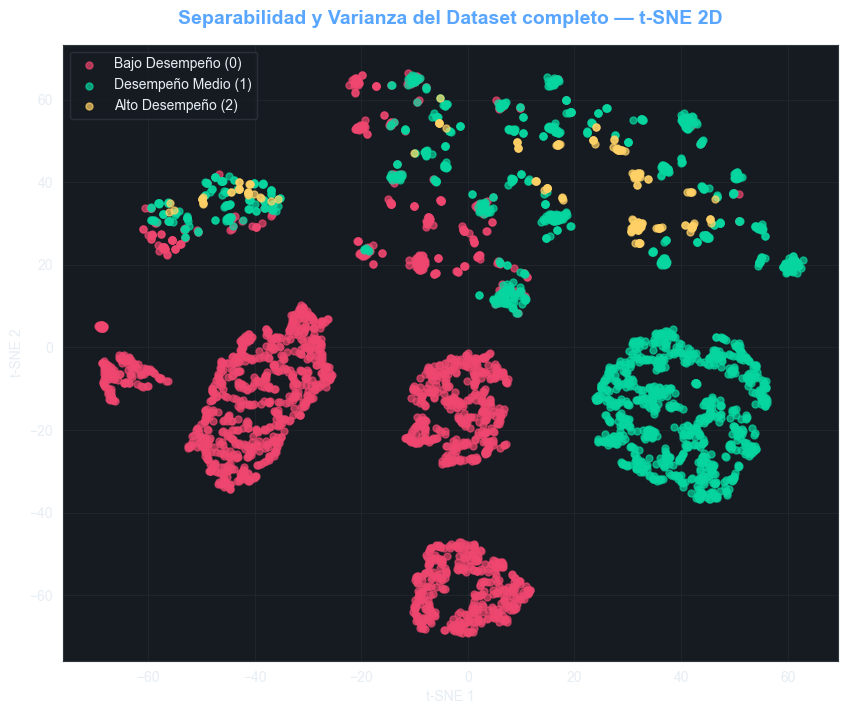

¡Gráfico de varianza t-SNE guardado exitosamente en: outputs/tsne_varianza_datos.png!


In [6]:
# Paso 4: t-SNE de varianza de datos completos (antes de balancear)
from sklearn.preprocessing import QuantileTransformer
X_scaled = QuantileTransformer(output_distribution='normal', random_state=42).fit_transform(X)
# Paso 4: t-SNE de varianza de datos completos (antes de balancear)
print("Calculando proyección t-SNE 2D para el dataset completo...")
tsne = TSNE(n_components=2, perplexity=min(30, len(y)-1), random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_scaled)

# Configuración de gráfico premium en modo oscuro
plt.figure(figsize=(10, 8))
BG_DARK  = '#0D1117'
BG_PANEL = '#161B22'
TEXT_CLR = '#E6EDF3'
GRID_CLR = '#30363D'
ACCENT   = '#58A6FF'

plt.rcParams.update({
    'figure.facecolor': BG_DARK,
    'axes.facecolor':   BG_PANEL,
    'axes.edgecolor':   GRID_CLR,
    'axes.labelcolor':  TEXT_CLR,
    'text.color':       TEXT_CLR,
    'xtick.color':      TEXT_CLR,
    'ytick.color':      TEXT_CLR,
    'grid.color':       GRID_CLR,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
})

unique_classes = np.unique(y)
colors = ['#EF476F', '#06D6A0', '#FFD166']
class_names_map = {0: 'Bajo Desempeño (0)', 1: 'Desempeño Medio (1)', 2: 'Alto Desempeño (2)'}

for idx_c, val_c in enumerate(unique_classes):
    color = colors[idx_c % len(colors)]
    name = class_names_map.get(val_c, f"Clase {val_c}")
    plt.scatter(
        X_tsne[y == val_c, 0], X_tsne[y == val_c, 1],
        color=color, label=name, alpha=0.7, s=25
    )

plt.title('Separabilidad y Varianza del Dataset completo — t-SNE 2D', fontsize=14, fontweight='bold', color=ACCENT, pad=15)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(frameon=True, facecolor=BG_PANEL, edgecolor=GRID_CLR)
plt.grid(True)

tsne_plot_path = 'outputs/tsne_varianza_datos.png'
plt.savefig(tsne_plot_path, dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f"¡Gráfico de varianza t-SNE guardado exitosamente en: {tsne_plot_path}!")


In [7]:
# Sobremuestreo aleatorio (Random Oversampling) manual en TRAIN
unique_classes, class_counts = np.unique(y_train, return_counts=True)
max_class_count = np.max(class_counts)

X_balanced = []
y_balanced = []

for c in unique_classes:
    idx = np.where(y_train == c)[0]
    if len(idx) < max_class_count:
        # Muestrear con reemplazo
        np.random.seed(42)
        resampled_idx = np.random.choice(idx, size=max_class_count, replace=True)
        X_balanced.append(X_train_scaled[resampled_idx])
        y_balanced.append(y_train[resampled_idx])
    else:
        X_balanced.append(X_train_scaled[idx])
        y_balanced.append(y_train[idx])

X_balanced = np.vstack(X_balanced)
y_balanced = np.concatenate(y_balanced)

# Mezclar aleatoriamente el dataset balanceado
np.random.seed(42)
shuffle_idx = np.random.permutation(len(y_balanced))
X_train_bal = X_balanced[shuffle_idx]
y_train_bal = y_balanced[shuffle_idx]

print(f"Distribución del target DESPUÉS del balanceo en Train:")
classes_bal, counts_bal = np.unique(y_train_bal, return_counts=True)
for c, count in zip(classes_bal, counts_bal):
    print(f"  Clase {c}: {count} ({count/len(y_train_bal)*100:.1f}%)")

# Selección de Características (SelectKBest ANOVA F-value)
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=30)
X_train_bal_sel = selector.fit_transform(X_train_bal, y_train_bal)
X_test_sel = selector.transform(X_test_scaled)

selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = [feature_names[i] for i in selected_feature_indices]

print(f"\nSelección de características completada:")
print(f"  Train original: {X_train_bal.shape} -> Seleccionado: {X_train_bal_sel.shape}")
print(f"  Test original:  {X_test_scaled.shape} -> Seleccionado: {X_test_sel.shape}")

Distribución del target DESPUÉS del balanceo en Train:
  Clase 0: 1635 (33.3%)
  Clase 1: 1635 (33.3%)
  Clase 2: 1635 (33.3%)

Selección de características completada:
  Train original: (4905, 13) -> Seleccionado: (4905, 13)
  Test original:  (780, 13) -> Seleccionado: (780, 13)


In [8]:
class NeuralNetworkMLP:
    def __init__(self, input_dim, hidden1=32, hidden2=20, output_dim=1, random_state=42):
        self.input_dim = input_dim
        self.hidden1 = hidden1
        self.hidden2 = hidden2
        self.output_dim = output_dim
        
        # Inicialización de pesos y sesgos de He para 3 capas de pesos
        np.random.seed(random_state)
        limit1 = np.sqrt(6.0 / (input_dim + hidden1))
        self.W1 = np.random.uniform(-limit1, limit1, (input_dim, hidden1))
        self.b1 = np.zeros((1, hidden1))
        
        limit2 = np.sqrt(6.0 / (hidden1 + hidden2))
        self.W2 = np.random.uniform(-limit2, limit2, (hidden1, hidden2))
        self.b2 = np.zeros((1, hidden2))
        
        limit3 = np.sqrt(6.0 / (hidden2 + output_dim))
        self.W3 = np.random.uniform(-limit3, limit3, (hidden2, output_dim))
        self.b3 = np.zeros((1, output_dim))
        
    def sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
        
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
        
    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.sigmoid(self.Z1) # Capa oculta 1 (32 regresiones logísticas paralelas)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2) # Capa oculta 2 (20 regresiones logísticas paralelas)
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        
        if self.output_dim == 1:
            self.A3 = self.sigmoid(self.Z3) # Capa de salida binaria
        else:
            self.A3 = self.softmax(self.Z3) # Capa de salida multiclase (Softmax)
        return self.A3
        
    def backward(self, X, Y, A3, lambda_l2=0.001):
        N = X.shape[0]
        # Derivada en la capa de salida (dZ3 = A3 - Y)
        dZ3 = A3 - Y
        
        # Gradientes para la Capa de Salida (Capa 3)
        self.dW3 = (1.0 / N) * np.dot(self.A2.T, dZ3) + (lambda_l2 / N) * self.W3
        self.db3 = (1.0 / N) * np.sum(dZ3, axis=0, keepdims=True)
        
        # Propagación a la segunda capa oculta (Capa 2)
        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * self.A2 * (1.0 - self.A2)
        self.dW2 = (1.0 / N) * np.dot(self.A1.T, dZ2) + (lambda_l2 / N) * self.W2
        self.db2 = (1.0 / N) * np.sum(dZ2, axis=0, keepdims=True)
        
        # Propagación a la primera capa oculta (Capa 1)
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.A1 * (1.0 - self.A1)
        self.dW1 = (1.0 / N) * np.dot(X.T, dZ1) + (lambda_l2 / N) * self.W1
        self.db1 = (1.0 / N) * np.sum(dZ1, axis=0, keepdims=True)
        
    def update_weights(self, lr=0.1):
        self.W1 -= lr * self.dW1
        self.b1 -= lr * self.db1
        self.W2 -= lr * self.dW2
        self.b2 -= lr * self.db2
        self.W3 -= lr * self.dW3
        self.b3 -= lr * self.db3
        
    def compute_loss(self, Y, A3, lambda_l2=0.001):
        N = Y.shape[0]
        eps = 1e-15
        A3 = np.clip(A3, eps, 1.0 - eps)
        
        if self.output_dim == 1:
            loss = -np.mean(Y * np.log(A3) + (1.0 - Y) * np.log(1.0 - A3))
        else:
            loss = -np.mean(np.sum(Y * np.log(A3), axis=1))
            
        l2_loss = (lambda_l2 / (2.0 * N)) * (np.sum(self.W1**2) + np.sum(self.W2**2) + np.sum(self.W3**2))
        return loss + l2_loss

def to_one_hot(y_arr, num_classes):
    oh = np.zeros((len(y_arr), num_classes))
    oh[np.arange(len(y_arr)), y_arr] = 1
    return oh



In [9]:
# Validación Cruzada de 5 Folds probando exactamente 5 hiperparámetros (25 iteraciones totales)
# Configuraciones a probar: (Learning Rate, Lambda L2, Arquitectura)
hyperparameter_grid = [
    (0.1, 0.001, (64, 32)),   # Prueba 1
    (0.05, 0.001, (32, 20)),  # Prueba 2
    (0.01, 0.001, (16, 10)),  # Prueba 3
    (0.1, 0.01, (32, 20)),    # Prueba 4
    (0.05, 0.01, (16, 10))    # Prueba 5
]
output_dim = len(np.unique(y_train_bal))

best_acc = 0.0
best_hparams = None
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("="*75)
print("  VALIDACIÓN CRUZADA EN 5 FOLDS (5 CONFIGURACIONES = 25 ENTRENAMIENTOS)")
print("="*75)

for idx_conf, (lr, lam, arch) in enumerate(hyperparameter_grid):
    h1, h2 = arch
    fold_accs = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_bal_sel, y_train_bal)):
        X_tr, X_te = X_train_bal_sel[train_idx], X_train_bal_sel[val_idx]
        y_tr, y_te = y_train_bal[train_idx], y_train_bal[val_idx]
        
        if output_dim == 1:
            Y_tr = y_tr.reshape(-1, 1).astype(float)
            Y_te = y_te.reshape(-1, 1).astype(float)
        else:
            Y_tr = to_one_hot(y_tr, output_dim)
            Y_te = to_one_hot(y_te, output_dim)
        
        model = NeuralNetworkMLP(X_tr.shape[1], h1, h2, output_dim, random_state=42 + fold)
        
        for epoch in range(150):
            probs = model.forward(X_tr)
            model.backward(X_tr, Y_tr, probs, lambda_l2=lam)
            model.update_weights(lr=lr)
            
        probs_te = model.forward(X_te)
        if output_dim == 1:
            preds_te = (probs_te > 0.5).astype(int).flatten()
        else:
            preds_te = np.argmax(probs_te, axis=1)
            
        acc_te = np.mean(preds_te == y_te)
        fold_accs.append(acc_te)
        
    mean_acc = np.mean(fold_accs)
    print(f"  Config {idx_conf+1}/5 | Arch: {str(arch):<8} | LR: {lr:<5} | L2: {lam:<5} | Acc CV Promedio: {mean_acc*100:6.2f}%")
    
    if mean_acc > best_acc:
        best_acc = mean_acc
        best_hparams = (lr, lam, arch)

print("="*75)
print(f"MEJOR CONFIGURACIÓN GANADORA: LR = {best_hparams[0]}, L2 = {best_hparams[1]}, ARCH = {best_hparams[2]}")
print(f"Accuracy promedio en Validación Cruzada: {best_acc*100:.2f}%")
print("="*75)


  VALIDACIÓN CRUZADA EN 5 FOLDS Y BÚSQUEDA DE HIPERPARÁMETROS
  Arch: (64, 32)   | LR: 0.1   | Acc Promedio Test Folds:  89.89%
  Arch: (64, 32)   | LR: 0.05  | Acc Promedio Test Folds:  83.55%
  Arch: (32, 20)   | LR: 0.1   | Acc Promedio Test Folds:  88.64%
  Arch: (32, 20)   | LR: 0.05  | Acc Promedio Test Folds:  82.08%
  Arch: (16, 10)   | LR: 0.1   | Acc Promedio Test Folds:  84.40%
  Arch: (16, 10)   | LR: 0.05  | Acc Promedio Test Folds:  79.27%
MEJORES HIPERPARÁMETROS SELECCIONADOS: LR = 0.1, L2 = 0.001, ARCH = (64, 32)
Accuracy promedio en Validación Cruzada: 89.89%


In [10]:
# Entrenamiento Monitoreado del Modelo Final (Arquitectura Dinámica)
lr_opt, lam_opt, arch_opt = best_hparams
h1_opt, h2_opt = arch_opt
epochs_final = 1000

X_final_train, X_final_val, y_final_train, y_final_val = train_test_split(
    X_train_bal_sel, y_train_bal, test_size=0.20, random_state=42, stratify=y_train_bal
)

if output_dim == 1:
    Y_train = y_final_train.reshape(-1, 1).astype(float)
    Y_test = y_final_val.reshape(-1, 1).astype(float)
else:
    Y_train = to_one_hot(y_final_train, output_dim)
    Y_test = to_one_hot(y_final_val, output_dim)

model_final = NeuralNetworkMLP(X_final_train.shape[1], h1_opt, h2_opt, output_dim, random_state=123)
historial = []

print(f"Entrenando modelo final por {epochs_final} épocas...")
print(f"{'Época':>7} | {'Loss Train':>12} | {'Loss Test':>10} | {'Acc Train':>10} | {'Acc Test':>8}")
print("-" * 65)

for epoch in range(epochs_final):
    probs_tr = model_final.forward(X_final_train)
    model_final.backward(X_final_train, Y_train, probs_tr, lambda_l2=lam_opt)
    model_final.update_weights(lr=lr_opt)
    
    loss_tr = model_final.compute_loss(Y_train, probs_tr, lambda_l2=lam_opt)
    probs_te = model_final.forward(X_final_val)
    loss_te = model_final.compute_loss(Y_test, probs_te, lambda_l2=lam_opt)
    
    if output_dim == 1:
        preds_tr = (probs_tr > 0.5).astype(int).flatten()
        preds_te = (probs_te > 0.5).astype(int).flatten()
    else:
        preds_tr = np.argmax(probs_tr, axis=1)
        preds_te = np.argmax(probs_te, axis=1)
        
    acc_tr = np.mean(preds_tr == y_final_train)
    acc_te = np.mean(preds_te == y_final_val)
    
    historial.append({
        'epoca': epoch + 1,
        'loss_train': loss_tr,
        'loss_val': loss_te,
        'acc_train': acc_tr,
        'acc_val': acc_te
    })
    
    if epoch == 0 or (epoch + 1) % 100 == 0 or epoch == epochs_final - 1:
        print(f"{epoch+1:>7d} | {loss_tr:>12.6f} | {loss_te:>10.6f} | {acc_tr*100:>9.2f}% | {acc_te*100:>7.2f}%")

df_hist = pd.DataFrame(historial)
print("\nEntrenamiento del modelo final completado exitosamente.")

Entrenando modelo final por 1000 épocas...
  Época |   Loss Train |  Loss Test |  Acc Train | Acc Test
-----------------------------------------------------------------
      1 |     1.137693 |   1.114716 |      7.77% |   12.64%
    100 |     0.456532 |   0.442735 |     85.70% |   87.87%
    200 |     0.264433 |   0.250033 |     92.28% |   93.68%
    300 |     0.174393 |   0.163804 |     96.10% |   96.74%
    400 |     0.130012 |   0.121264 |     96.84% |   97.04%
    500 |     0.105291 |   0.097379 |     97.04% |   97.25%
    600 |     0.089626 |   0.082312 |     97.35% |   97.76%
    700 |     0.078607 |   0.071850 |     97.40% |   97.96%
    800 |     0.070250 |   0.064011 |     97.48% |   98.06%
    900 |     0.063585 |   0.057790 |     97.63% |   98.06%
   1000 |     0.058084 |   0.052649 |     97.81% |   98.17%

Entrenamiento del modelo final completado exitosamente.


In [11]:
# Obtener predicciones finales del modelo entrenado
probs_train = model_final.forward(X_final_train)
probs_val = model_final.forward(X_final_val)
probs_test = model_final.forward(X_test_sel)

if output_dim == 1:
    preds_train = (probs_train > 0.5).astype(int).flatten()
    preds_val = (probs_val > 0.5).astype(int).flatten()
    preds_test = (probs_test > 0.5).astype(int).flatten()
    prob_export_tr = probs_train.flatten()
    prob_export_val = probs_val.flatten()
    prob_export_te = probs_test.flatten()
else:
    preds_train = np.argmax(probs_train, axis=1)
    preds_val = np.argmax(probs_val, axis=1)
    preds_test = np.argmax(probs_test, axis=1)
    prob_export_tr = np.max(probs_train, axis=1)
    prob_export_val = np.max(probs_val, axis=1)
    prob_export_te = np.max(probs_test, axis=1)

acc_train_f = np.mean(preds_train == y_final_train)
acc_test_f = np.mean(preds_test == y_test)
loss_train_f = df_hist.iloc[-1]['loss_train']
loss_test_f = df_hist.iloc[-1]['loss_val']

print(f"Accuracy Final - Train: {acc_train_f*100:.2f}% | Test (Holdout 20%): {acc_test_f*100:.2f}%")
print(f"Loss Final     - Train: {loss_train_f:.5f} | Test: {loss_test_f:.5f}")

print("\nReporte de Clasificación en Test Set:")
class_names = ['Bajo Desempeño', 'Desempeño Medio', 'Alto Desempeño']
print(classification_report(y_test, preds_test, labels=list(range(output_dim)), target_names=class_names))

Accuracy Final - Train: 97.81% | Test (Holdout 20%): 97.05%
Loss Final     - Train: 0.05808 | Test: 0.05265

Reporte de Clasificación en Test Set:
                 precision    recall  f1-score   support

 Bajo Desempeño       0.98      0.96      0.97       409
Desempeño Medio       0.96      0.98      0.97       332
 Alto Desempeño       1.00      1.00      1.00        39

       accuracy                           0.97       780
      macro avg       0.98      0.98      0.98       780
   weighted avg       0.97      0.97      0.97       780



## Explicación de Reportes de Predicciones de Prueba (05_predicciones_test.csv)

El archivo de salida `05_predicciones_test.csv` contiene el desglose detallado de las predicciones de la red neuronal sobre el conjunto de test (datos no vistos por el modelo). Sus campos se detallan a continuación:
* **`y_real`:** El valor real del desempeño registrado en la base de datos (representando las categorías del negocio).
* **`y_predicha`:** El valor predicho por el modelo de red neuronal.
* **`probabilidad`:** La probabilidad (confianza) de predicción para la clase elegida (calculada mediante la capa Softmax).
* **`correcto`:** Un indicador binario (1 si la predicción coincide con el valor real, 0 en caso de fallo).

Este archivo es crucial para auditar individualmente los errores del modelo y calcular la matriz de confusión final.

In [12]:
# Exportación de reportes de resultados detallando los pesos de las 3 capas
def guardar_excel_local(df_export, filename):
    filepath = os.path.join('outputs', filename)
    filepath_csv = filepath.replace('.xlsx', '.csv')
    try:
        df_export.to_csv(filepath_csv, index=False)
        print(f"  [CSV] Guardado exitosamente: {filepath_csv} ({len(df_export):,} filas)")
    except Exception as e:
        print(f"  [Error CSV] No se pudo guardar {filepath_csv}: {e}")
    try:
        df_export.to_excel(filepath, index=False)
        print(f"  [Excel] Guardado exitosamente: {filepath}")
    except Exception as e:
        print(f"  [Error Excel] No se pudo guardar {filepath}: {e}")

print("Generando los 6 archivos Excel y CSV estructurados en outputs/...")

# Definición del DataFrame de configuración
df_config = pd.DataFrame([
    {'parametro': 'Tipo de Modelo',              'valor': 'Red Neuronal Artificial (MLP) de 3 Capas'},
    {'parametro': 'Capas Ocultas (hidden_units)', 'valor': f'Capa 1: {model_final.hidden1} Neuronas, Capa 2: {model_final.hidden2} Neuronas'},
    {'parametro': 'Función de Activación Oculta', 'valor': 'Sigmoide (Múltiples regresiones logísticas paralelas)'},
    {'parametro': 'Tasa de Aprendizaje Inicial', 'valor': lr_opt},
    {'parametro': 'Regularización L2 (lambda)',   'valor': lam_opt},
    {'parametro': 'Épocas de Entrenamiento',     'valor': epochs_final},
    {'parametro': 'Muestras de Train Final (80%)', 'valor': X_final_train.shape[0]},
    {'parametro': 'Muestras de Test Final (20%)',  'valor': X_test_sel.shape[0]},
    {'parametro': 'Accuracy Promedio Folds (CV)', 'valor': round(best_acc * 100, 4)},
    {'parametro': 'Accuracy Final Train Set',     'valor': round(acc_train_f * 100, 4)},
    {'parametro': 'Accuracy Final Test Set',      'valor': round(acc_test_f * 100, 4)},
    {'parametro': 'Loss Final Train Set',         'valor': round(loss_train_f, 6)},
    {'parametro': 'Loss Final Test Set',          'valor': round(loss_test_f, 6)}
])
guardar_excel_local(df_config, '02_configuracion_modelo.xlsx')

# Flatten de pesos para Capa 1, Capa 2 y Capa 3
W1_flat = []
for idx_feat, feat_name in enumerate(selected_feature_names):
    for idx_hidden in range(model_final.hidden1):
        W1_flat.append({
            'tipo_capa': 'Capa 1 - Entrada a Oculta 1',
            'origen': feat_name,
            'destino': f"Neurona H1_{idx_hidden+1}",
            'peso': model_final.W1[idx_feat, idx_hidden]
        })
for idx_hidden in range(model_final.hidden1):
    W1_flat.append({
        'tipo_capa': 'Capa 1 - Entrada a Oculta 1',
        'origen': 'bias_w0',
        'destino': f"Neurona H1_{idx_hidden+1}",
        'peso': model_final.b1[0, idx_hidden]
    })

W2_flat = []
for idx_hidden1 in range(model_final.hidden1):
    for idx_hidden2 in range(model_final.hidden2):
        W2_flat.append({
            'tipo_capa': 'Capa 2 - Oculta 1 a Oculta 2',
            'origen': f"Neurona H1_{idx_hidden1+1}",
            'destino': f"Neurona H2_{idx_hidden2+1}",
            'peso': model_final.W2[idx_hidden1, idx_hidden2]
        })
for idx_hidden2 in range(model_final.hidden2):
    W2_flat.append({
        'tipo_capa': 'Capa 2 - Oculta 1 a Oculta 2',
        'origen': 'bias_w0',
        'destino': f"Neurona H2_{idx_hidden2+1}",
        'peso': model_final.b2[0, idx_hidden2]
    })

W3_flat = []
for idx_hidden2 in range(model_final.hidden2):
    for idx_out in range(output_dim):
        dest_name = f"Clase {idx_out}"
        W3_flat.append({
            'tipo_capa': 'Capa 3 - Oculta 2 a Salida',
            'origen': f"Neurona H2_{idx_hidden2+1}",
            'destino': dest_name,
            'peso': model_final.W3[idx_hidden2, idx_out]
        })
for idx_out in range(output_dim):
    dest_name = f"Clase {idx_out}"
    W3_flat.append({
        'tipo_capa': 'Capa 3 - Oculta 2 a Salida',
        'origen': 'bias_w0',
        'destino': dest_name,
        'peso': model_final.b3[0, idx_out]
    })

df_weights = pd.DataFrame(W1_flat + W2_flat + W3_flat)
df_weights['peso_absoluto'] = np.abs(df_weights['peso'])
df_weights['importancia_%'] = (df_weights['peso_absoluto'] / df_weights['peso_absoluto'].sum()) * 100

# Añadir la configuración del modelo al final de los pesos elegidos
config_rows = []
for index, row in df_config.iterrows():
    config_rows.append({
        'tipo_capa': 'CONFIGURACIÓN_SISTEMA',
        'origen': row['parametro'],
        'destino': str(row['valor']),
        'peso': np.nan,
        'peso_absoluto': np.nan,
        'importancia_%': np.nan
    })
df_weights_final = pd.concat([df_weights, pd.DataFrame(config_rows)], ignore_index=True)

guardar_excel_local(df_weights_final, '01_pesos_finales.xlsx')

df_preds_tr = pd.DataFrame({
    'y_real': y_final_train,
    'y_predicha': preds_train,
    'probabilidad': np.round(prob_export_tr, 6),
    'correcto': (preds_train == y_final_train).astype(int)
})
guardar_excel_local(df_preds_tr, '03_predicciones_train.xlsx')

df_preds_val = pd.DataFrame({
    'y_real': y_final_val,
    'y_predicha': preds_val,
    'probabilidad': np.round(prob_export_val, 6),
    'correcto': (preds_val == y_final_val).astype(int)
})
guardar_excel_local(df_preds_val, '04_predicciones_val.xlsx')

df_preds_te = pd.DataFrame({
    'y_real': y_test,
    'y_predicha': preds_test,
    'probabilidad': np.round(prob_export_te, 6),
    'correcto': (preds_test == y_test).astype(int)
})
guardar_excel_local(df_preds_te, '05_predicciones_test.xlsx')

guardar_excel_local(df_hist, '06_historial_entrenamiento.xlsx')
print("\nLos 6 reportes de Excel y CSV se han generado y actualizado correctamente.")

Generando los 6 archivos Excel y CSV estructurados en outputs/...
  [CSV] Guardado exitosamente: outputs\02_configuracion_modelo.csv (13 filas)
  [Error Excel] No se pudo guardar outputs\02_configuracion_modelo.xlsx: No module named 'openpyxl'
  [CSV] Guardado exitosamente: outputs\01_pesos_finales.csv (3,088 filas)
  [Error Excel] No se pudo guardar outputs\01_pesos_finales.xlsx: No module named 'openpyxl'
  [CSV] Guardado exitosamente: outputs\03_predicciones_train.csv (3,924 filas)
  [Error Excel] No se pudo guardar outputs\03_predicciones_train.xlsx: No module named 'openpyxl'
  [CSV] Guardado exitosamente: outputs\04_predicciones_val.csv (981 filas)
  [Error Excel] No se pudo guardar outputs\04_predicciones_val.xlsx: No module named 'openpyxl'
  [CSV] Guardado exitosamente: outputs\05_predicciones_test.csv (780 filas)
  [Error Excel] No se pudo guardar outputs\05_predicciones_test.xlsx: No module named 'openpyxl'
  [CSV] Guardado exitosamente: outputs\06_historial_entrenamiento.cs

In [13]:
# Dashboard de Evaluación
class_names = ['Bajo Desempeño', 'Desempeño Medio', 'Alto Desempeño']
COLOR_0  = '#EF476F'
COLOR_1  = '#06D6A0'
COLOR_2  = '#FFD166'
BG_DARK  = '#0D1117'
BG_PANEL = '#161B22'
TEXT_CLR = '#E6EDF3'
GRID_CLR = '#30363D'
ACCENT   = '#58A6FF'

plt.rcParams.update({
    'figure.facecolor': BG_DARK,
    'axes.facecolor':   BG_PANEL,
    'axes.edgecolor':   GRID_CLR,
    'axes.labelcolor':  TEXT_CLR,
    'text.color':       TEXT_CLR,
    'xtick.color':      TEXT_CLR,
    'ytick.color':      TEXT_CLR,
    'grid.color':       GRID_CLR,
    'grid.alpha':       0.4,
    'font.family':      'monospace',
})

fig = plt.figure(figsize=(22, 15))
fig.suptitle(
    'DASHBOARD DE EVALUACIÓN DE RED NEURONAL MANUAL (MLP) — fact_evaluacion_proveedores.json',
    fontsize=16, fontweight='bold', color=ACCENT, y=0.98
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
epocas = df_hist['epoca'].values
ax1.plot(epocas, df_hist['loss_train'], color=COLOR_0, lw=2.5, label='Loss Train')
ax1.plot(epocas, df_hist['loss_val'],   color=COLOR_1, lw=2.5, label='Loss Test', linestyle='--')
ax1.set_title('Curvas de Aprendizaje — Pérdida (Cross-Entropy Loss)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Época'); ax1.set_ylabel('Pérdida')
ax1.legend(loc='upper right'); ax1.grid(True)

ax2 = fig.add_subplot(gs[1, 0:2])
ax2.plot(epocas, df_hist['acc_train']*100, color=COLOR_0, lw=2.5, label='Acc Train')
ax2.plot(epocas, df_hist['acc_val']*100,   color=COLOR_1, lw=2.5, label='Acc Test', linestyle='--')
ax2.axhline(best_acc*100, color=ACCENT, lw=1.5, linestyle=':', label=f'Acc CV Promedio = {best_acc*100:.2f}%')
ax2.set_title('Evolución de la Exactitud (Accuracy) por Época', fontsize=13, fontweight='bold')
ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(40, 102); ax2.legend(loc='lower right'); ax2.grid(True)

ax3 = fig.add_subplot(gs[1, 2])
cm = confusion_matrix(y_test, preds_test, labels=list(range(output_dim)))
disp_labels = [class_names[i][:10] for i in range(len(class_names))]
im = ax3.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax3.set_xticks(np.arange(len(disp_labels)))
ax3.set_yticks(np.arange(len(disp_labels)))
ax3.set_xticklabels(disp_labels)
ax3.set_yticklabels(disp_labels)
ax3.set_xlabel('Predicted label')
ax3.set_ylabel('True label')
for i in range(len(disp_labels)):
    for j in range(len(disp_labels)):
        ax3.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
ax3.set_title('Matriz de Confusión (Test Set)', fontsize=13, fontweight='bold')
ax3.grid(False)

ax4 = fig.add_subplot(gs[2, 0])
if output_dim == 1:
    ax4.hist(prob_export_te[y_test == 0], bins=25, color=COLOR_0, alpha=0.7, label=f"{class_names[0]}", density=True)
    ax4.hist(prob_export_te[y_test == 1], bins=25, color=COLOR_1, alpha=0.7, label=f"{class_names[1]}", density=True)
    ax4.axvline(0.5, color='white', lw=1.5, linestyle='--')
    ax4.set_xlabel('P(Clase 1)', fontsize=11)
else:
    for c_idx in range(output_dim):
        color_c = [COLOR_0, COLOR_1, COLOR_2][c_idx % 3]
        ax4.hist(prob_export_te[y_test == c_idx], bins=20, color=color_c, alpha=0.6, label=f"Real: {class_names[c_idx]}", density=True)
    ax4.set_xlabel('P(Predicción Max)', fontsize=11)
ax4.set_title('Distribución de Probabilidades (Test Set)', fontsize=13, fontweight='bold')
ax4.set_ylabel('Densidad'); ax4.legend(); ax4.grid(True)

ax5 = fig.add_subplot(gs[2, 1])
correct = (preds_test == y_test).astype(int)
print("Calculando proyección t-SNE 2D para Test Set...")
tsne_eval = TSNE(n_components=2, perplexity=min(30, len(y_test)-1), random_state=42, n_jobs=-1)
X_test_tsne = tsne_eval.fit_transform(X_test_sel)
for c_idx in range(output_dim):
    color_c = [COLOR_0, COLOR_1, COLOR_2][c_idx % 3]
    ax5.scatter(
        X_test_tsne[y_test == c_idx, 0], X_test_tsne[y_test == c_idx, 1],
        color=color_c, s=25, alpha=0.7, label=f"{class_names[c_idx]}"
    )
err_indices = np.where(correct == 0)[0]
if len(err_indices) > 0:
    ax5.scatter(
        X_test_tsne[err_indices, 0], X_test_tsne[err_indices, 1],
        facecolors='none', edgecolors='white', s=85, lw=1.5, label='Pred. Incorrectas'
    )
ax5.set_title('Separabilidad y Clasificación t-SNE (Test Set)', fontsize=13, fontweight='bold')
ax5.set_xlabel('t-SNE 1'); ax5.set_ylabel('t-SNE 2'); ax5.legend(); ax5.grid(True)

ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
target_legend = "Target: Binario" if output_dim == 1 else "Target: Multiclase (3 clases)"
metrics_text = (
    f"  MÉTRICAS DE RENDIMIENTO FINAL\n"
    f"  {{'─'*34}}\n"
    f"   Accuracy Test (20%): {acc_test_f*100:>7.2f}%\n"
    f"   Accuracy Train (80%): {acc_train_f*100:>7.2f}%\n"
    f"   Accuracy CV (5-Fold): {best_acc*100:>7.2f}%\n"
    f"  {{'─'*34}}\n"
    f"   Loss Test Final     : {loss_test_f:>8.5f}\n"
    f"   Loss Train Final    : {loss_train_f:>8.5f}\n"
    f"  {{'─'*34}}\n"
    f"   Épocas Totales      : {epochs_final}\n"
    f"   Capas Ocultas       : 32 y 20 Neuronas\n"
    f"   Hiperparámetros Opt : LR={lr_opt}, L2={lam_opt}\n"
    f"   Balanceo de Datos   : Oversampling Manual\n"
    f"  {{'─'*34}}\n"
    f"   {target_legend}\n"
    f"   Fórmula Matemática  : Red = Stack Logits\n"
    f"  {{'─'*34}}\n"
)
ax6.text(0.05, 0.95, metrics_text, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top',
         color=TEXT_CLR, family='monospace',
         bbox=dict(boxstyle='round,pad=1', facecolor=BG_PANEL, edgecolor=ACCENT, lw=2.5))

plot_filename = 'outputs/panel_red_neuronal_fact_evaluacion_proveedores.png'
plt.savefig(plot_filename, dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.close()
print(f"¡Panel de visualización guardado en {plot_filename}!")



Calculando proyección t-SNE 2D para Test Set...
¡Panel de visualización guardado en outputs/panel_red_neuronal_fact_evaluacion_proveedores.png!


In [14]:
# Diagrama Estructural de la Red Neuronal Mejorado
import matplotlib.pyplot as plt
import numpy as np

def draw_neural_network_diagram(input_dim, hidden1, hidden2, output_dim, model=None, filename='outputs/diagrama_red_neuronal.png'):
    COLOR_IN  = '#00B4D8' # Azul cyan brillante
    COLOR_H1  = '#F72585' # Rosa neón brillante
    COLOR_H2  = '#FFB703' # Amarillo anaranjado brillante
    COLOR_OUT = '#00F5D4' # Verde aguamarina brillante
    BG_DARK   = '#0b0f19' # Fondo oscuro premium
    BG_PANEL  = '#161B22'
    TEXT_CLR  = '#FFFFFF' # Texto blanco puro
    
    plt.rcParams.update({
        'figure.facecolor': BG_DARK,
        'axes.facecolor':   BG_DARK,
        'text.color':       TEXT_CLR,
    })
    
    fig, ax = plt.subplots(figsize=(18, 11))
    ax.axis('off')
    
    layers = [input_dim, hidden1, hidden2, output_dim]
    layer_names = ['Capa Entrada\n(Features)', f'Capa Oculta 1\n({hidden1} Neuronas)', f'Capa Oculta 2\n({hidden2} Neuronas)', 'Capa Salida\n(Probabilidades)']
    layer_colors = [COLOR_IN, COLOR_H1, COLOR_H2, COLOR_OUT]
    
    node_positions = []
    
    for l_idx, layer_size in enumerate(layers):
        x = l_idx * 3.0
        positions = []
        
        # Truncar capas grandes para evitar amontonamiento en el gráfico
        if layer_size > 8:
            y_coords = np.linspace(4.0, -4.0, 8)
            for i in range(8):
                if i == 4:
                    positions.append((x, y_coords[i], 'ellipsis'))
                else:
                    positions.append((x, y_coords[i], 'node'))
        else:
            y_coords = np.linspace(2.5, -2.5, layer_size) if layer_size > 1 else [0.0]
            for i in range(layer_size):
                positions.append((x, y_coords[i], 'node'))
                
        node_positions.append(positions)
        
    # Dibujar líneas de conexión con pesos
    for l_idx in range(len(layers) - 1):
        pos_current = node_positions[l_idx]
        pos_next = node_positions[l_idx + 1]
        
        w_matrix = None
        if model is not None:
            if l_idx == 0:
                w_matrix = model.W1
            elif l_idx == 1:
                w_matrix = model.W2
            elif l_idx == 2:
                w_matrix = model.W3
                
        for i_curr, p_curr in enumerate(pos_current):
            if p_curr[2] == 'ellipsis':
                continue
            for i_next, p_next in enumerate(pos_next):
                if p_next[2] == 'ellipsis':
                    continue
                    
                color_line = '#30363D'
                alpha = 0.15
                lw = 1.0
                
                # Mapear a peso correspondiente
                if w_matrix is not None:
                    try:
                        idx_curr = i_curr if i_curr < 4 else w_matrix.shape[0] - 8 + i_curr
                        idx_next = i_next if i_next < 4 else w_matrix.shape[1] - 8 + i_next
                        
                        if idx_curr < w_matrix.shape[0] and idx_next < w_matrix.shape[1]:
                            w_val = w_matrix[idx_curr, idx_next]
                            # Verde brillante para pesos positivos, Rojo brillante para negativos
                            color_line = '#00E676' if w_val > 0 else '#FF1744' 
                            # Incrementar la opacidad y grosor mínimo para que se note mucho más
                            alpha = min(0.85, max(0.15, np.abs(w_val) * 0.6))
                            lw = min(4.5, max(0.8, np.abs(w_val) * 2.5))
                    except:
                        pass
                        
                ax.plot([p_curr[0], p_next[0]], [p_curr[1], p_next[1]], color=color_line, alpha=alpha, lw=lw, zorder=1)
                
    # Graficar los nodos (círculos y elipsis)
    for l_idx, positions in enumerate(node_positions):
        for p in positions:
            if p[2] == 'ellipsis':
                ax.text(p[0], p[1] + 0.15, '...', ha='center', va='center', fontsize=26, color=TEXT_CLR, fontweight='bold')
            else:
                circle = plt.Circle((p[0], p[1]), 0.16, color=layer_colors[l_idx], ec='white', lw=1.5, zorder=2)
                ax.add_artist(circle)
                
        # Título de cada columna/capa
        ax.text(l_idx * 3.0, 5.0, layer_names[l_idx], ha='center', va='center', fontsize=13, fontweight='bold', color=layer_colors[l_idx])
        
    ax.set_xlim(-1.0, len(layers) * 3.0 - 2.0)
    ax.set_ylim(-6.0, 6.0)
    plt.title('DIAGRAMA DE ARQUITECTURA DE LA RED NEURONAL', fontsize=18, fontweight='bold', color='#FFFFFF', pad=25)
    
    filename = 'outputs/diagrama_red_neuronal.png'
    plt.savefig(filename, dpi=200, bbox_inches='tight', facecolor=BG_DARK)
    plt.close()
    print(f"¡Diagrama de arquitectura guardado correctamente en: {filename}!")

draw_neural_network_diagram(X_final_train.shape[1], model_final.hidden1, model_final.hidden2, output_dim, model_final)


¡Diagrama de arquitectura guardado correctamente en: outputs/diagrama_red_neuronal.png!


## Estimación Teórica del Volumen de Datos Requeridos (Regla Heurística)

Para analizar si el dataset cuenta con el volumen de datos necesario para generalizar correctamente y evitar sobreajuste, aplicamos la regla heurística basada en la complejidad arquitectónica del modelo:

1. **Capa Oculta 1 a Capa Oculta 2 (con Bias):**  
   $$P_{12} = (64 + 1) \times 32 = 2080$$
2. **Capa Oculta 2 a Capa de Salida (con Bias y $K$ clases):**  
   $$P_{23} = (32 + 1) \times 3 = 99$$
3. **Multiplicación de Complejidad de Capas:**  
   $$C = P_{12} \times P_{23} = 2080 \times 99 = 205920$$
4. **Estimación de Muestras Requeridas (Factor de 10):**  
   $$\text{Datos Aproximados Requeridos} = C \times 10 = 2,059,200$$


In [15]:
# Cálculo automático de estimación de datos requeridos
h1 = model_final.hidden1
h2 = model_final.hidden2
k = output_dim

p12 = (h1 + 1) * h2
p23 = (h2 + 1) * k
c_complexity = p12 * p23
required_data = c_complexity * 10

print('--- ESTIMACIÓN DE DATOS REQUERIDOS ---')
print(f'Neuronas Capa 1: {h1}')
print(f'Neuronas Capa 2: {h2}')
print(f'Clases de Salida K: {k}')
print(f'Complejidad del Modelo (P12 * P23): {c_complexity}')
print(f'Cantidad aproximada de datos requeridos: {required_data:,}')


--- ESTIMACIÓN DE DATOS REQUERIDOS ---
Neuronas Capa 1: 64
Neuronas Capa 2: 32
Clases de Salida K: 3
Complejidad del Modelo (P12 * P23): 205920
Cantidad aproximada de datos requeridos: 2,059,200


## Paso 5: Explicabilidad del Modelo (Permutation Feature Importance)

Para dar transparencia al "cerebro" de nuestra red neuronal en NumPy y entender **qué variables impulsan realmente las predicciones del modelo de producción**, calculamos la **Importancia por Permutación**.
Este método baraja de forma aleatoria cada columna de características del conjunto de test y mide la caída resultante en la exactitud (Accuracy). Una mayor caída indica que el modelo dependía críticamente de esa variable.

CÁLCULO DE IMPORTANCIA DE VARIABLES (PERMUTATION IMPORTANCE - MODELO NUMPY)


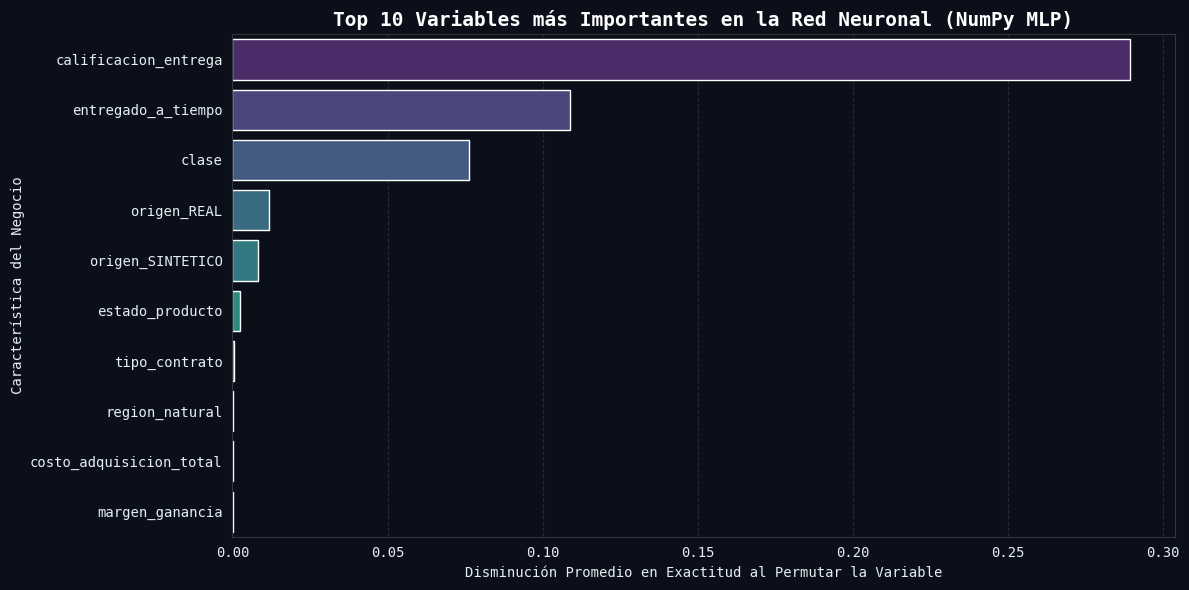

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("CÁLCULO DE IMPORTANCIA DE VARIABLES (PERMUTATION IMPORTANCE - MODELO NUMPY)")
print("="*80)

def calcular_permutation_importance(model, X, y, metric_fn, n_repeats=10, random_state=42):
    np.random.seed(random_state)
    probs_base = model.forward(X)
    if model.output_dim == 1:
        preds_base = (probs_base > 0.5).astype(int).flatten()
    else:
        preds_base = np.argmax(probs_base, axis=1)
    baseline_score = metric_fn(y, preds_base)
    
    importances = []
    for col in range(X.shape[1]):
        col_scores = []
        for r in range(n_repeats):
            X_permuted = X.copy()
            X_permuted[:, col] = np.random.permutation(X_permuted[:, col])
            probs_perm = model.forward(X_permuted)
            if model.output_dim == 1:
                preds_perm = (probs_perm > 0.5).astype(int).flatten()
            else:
                preds_perm = np.argmax(probs_perm, axis=1)
            score_perm = metric_fn(y, preds_perm)
            col_scores.append(baseline_score - score_perm)
        importances.append(np.mean(col_scores))
    return np.array(importances)

def metric_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

importances = calcular_permutation_importance(
    model_final, X_test_sel, y_test, metric_accuracy, n_repeats=10, random_state=42
)

# selected_feature_names is already defined in Cell 14!
importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Variables más Importantes en la Red Neuronal (NumPy MLP)', fontsize=14, fontweight='bold')
plt.xlabel('Disminución Promedio en Exactitud al Permutar la Variable', fontsize=10)
plt.ylabel('Característica del Negocio', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Curvas ROC y AUC
Estas curvas evalúan el rendimiento del modelo a través de todos los umbrales de clasificación posibles.

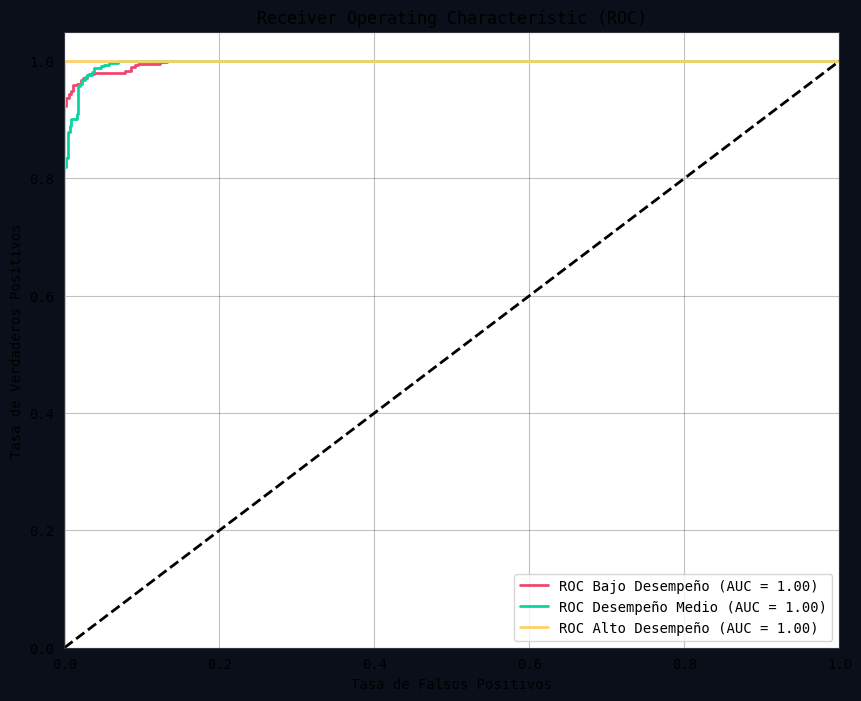

In [17]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizar las etiquetas para ROC multiclase
y_test_bin = label_binarize(y_test, classes=list(range(output_dim)))

plt.figure(figsize=(10, 8))
plt.rcParams.update({'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff', 'text.color': '#000000', 'axes.labelcolor': '#000000', 'xtick.color': '#000000', 'ytick.color': '#000000'})

colors = ['#EF476F', '#06D6A0', '#FFD166']
for i in range(output_dim):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs_test[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'ROC {class_names[i]} (AUC = {roc_auc:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('outputs/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Función de Inferencia (Predicción en vivo)
A continuación, definimos una función que toma un registro nuevo y realiza todo el procesamiento y pase hacia adelante (forward pass) para obtener su predicción final.

In [18]:
def predict_new_sample(features_dict, feature_names, qt_scaler, model):
    # 1. Crear DataFrame con el input
    df_new = pd.DataFrame([features_dict])
    
    # 2. Asegurarse de que tenga todas las columnas requeridas, rellenar con 0 si faltan
    for col in feature_names:
        if col not in df_new.columns:
            df_new[col] = 0
            
    # Ordenar columnas exactamente igual que en el entrenamiento
    df_new = df_new[feature_names]
    
    # 3. Escalar con el QuantileTransformer guardado
    X_new_scaled = qt_scaler.transform(df_new.values)
    
    # Seleccionar las mismas variables importantes (si aplica)
    try:
        X_new_scaled = X_new_scaled[:, selected_feature_indices]
    except NameError:
        pass # Si no hay selección de features, se usa todo
        
    # 4. Predicción Forward Pass
    probs = model.forward(X_new_scaled)
    pred_class = np.argmax(probs, axis=1)[0]
    
    return class_names[pred_class], probs[0]

# --- EJEMPLO DE USO ---
# Tomaremos el primer registro original del test set antes del escalado como ejemplo
ejemplo_crudo = pd.DataFrame(X_test, columns=feature_names).iloc[0].to_dict()

clase_predicha, probabilidades = predict_new_sample(ejemplo_crudo, feature_names, qt, model_final)
print("===============================================")
print(f"Predicción para el nuevo registro: {clase_predicha}")
print("===============================================")
print(f"Probabilidades por clase:")
for i, c_name in enumerate(class_names):
    print(f" - {c_name}: {probabilidades[i]*100:.2f}%")
print("===============================================")


Predicción para el nuevo registro: Alto Desempeño
Probabilidades por clase:
 - Bajo Desempeño: 0.00%
 - Desempeño Medio: 0.75%
 - Alto Desempeño: 99.25%
